In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
import plotly.express as px

In [2]:
# 1. Load the exported CSVs from your previous models
# Ensure you have saved 'career_results.csv' and 'performance_results.csv'
df_career = pd.read_csv('career_results.csv')
df_perf = pd.read_csv('performance_results.csv')

In [3]:
df_career.head()

,What was your course in UG?,What is your UG specialization? Major Subject (Eg; Mathematics),What are your interests?,What are your skills ? (Select multiple if necessary),What was the average CGPA or Percentage obtained in under graduation?,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster,PC1,PC2,PC3,Final_Cluster,SVD1,SVD2,SVD3
0,B.Sc,Computer Applications,Cloud computing,Python;SQL;Java,85,0,0,-1,0.119894,-0.871738,-0.764819,0,0.043571,0.172070,0.551008
1,B.E,Computer Science Engineering,Technology,"Critical Thinking, Analytic Thinking, SQL, Pro...",66.5,0,0,-1,0.147769,0.007347,-0.222954,6,0.454530,0.482331,0.865877
2,BA,Psychology,Understand human behaviour,People management;Communication skills,64.6,0,0,-1,1.211998,0.818000,0.664305,4,0.005794,0.012122,0.017656
3,MBA,Commerce,Sales/Marketing;Trading;Understand human behav...,Accounting Skills;Critical Thinking,75.525,0,0,-1,0.970265,0.471410,-0.848577,4,0.010637,0.022855,0.028238
4,B.Tech,Instrumentation Engineering,Technology,\nPLC Allen Bradley;PLC Ladder Logic;LabVIEW;B...,70.68,0,0,-1,-0.660689,0.336598,0.344374,7,1.116368,-0.020077,0.042301


In [4]:
df_perf.head()

,Scholarship Type,Weekly Study Hours,Midterm Preparation (When),Prep_encoded,Z_axis,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,3,5,1,0,0,2,2,0
1,3,1,1,0,0,0,1,1
2,2,1,1,0,0,0,1,1
3,1,1,1,0,0,0,1,1
4,1,4,2,1,0,1,0,2


In [5]:
# 2. Merge using the CORRECT column names to avoid KeyError
df_meta = pd.DataFrame({
    'Career_Cluster': df_career['Final_Cluster'],
    'Performance_Cluster': df_perf['KMeans_Cluster']
})

In [6]:
# Merge using the exact column names found in your data
df_meta = pd.DataFrame({
    'Career_Cluster': df_career['Final_Cluster'],
    'Performance_Cluster': df_perf['KMeans_Cluster'] # Changed from 'Final_Cluster' to match your data
})

# Drop any rows where data might not align perfectly
df_meta = df_meta.dropna()

print(f"Successfully created Meta-Dataframe with {len(df_meta)} rows.")

Successfully created Meta-Dataframe with 145 rows.


In [7]:
df_meta

,Career_Cluster,Performance_Cluster
0,0,2.0
1,6,0.0
2,4,0.0
3,4,0.0
4,7,1.0
...,...,...
140,1,2.0
141,5,0.0
142,4,2.0
143,0,1.0


In [8]:
# Safety check to identify which clustering column to use
perf_col = 'KMeans_Cluster' if 'KMeans_Cluster' in df_perf.columns else df_perf.columns[-1]
career_col = 'Final_Cluster' if 'Final_Cluster' in df_career.columns else df_career.columns[-1]

df_meta = pd.DataFrame({
    'Career_Cluster': df_career[career_col],
    'Performance_Cluster': df_perf[perf_col]
})

In [9]:
df_meta.head()

,Career_Cluster,Performance_Cluster
0,0,2.0
1,6,0.0
2,4,0.0
3,4,0.0
4,7,1.0


In [10]:
# Remove rows with missing values if any
df_meta = df_meta.dropna()
print(f"Meta-Dataframe created with {df_meta.shape[0]} students.")

Meta-Dataframe created with 145 students.


In [11]:
# Scale the clusters so the model treats Career and Performance with equal weight
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(df_meta)

In [12]:
X_meta_scaled

array([[-1.43052632,  0.63938181],
       [ 1.45039474, -1.3331791 ],
       [ 0.49008772, -1.3331791 ],
       [ 0.49008772, -1.3331791 ],
       [ 1.93054825, -0.34689864],
       [ 0.97024123,  0.63938181],
       [ 0.49008772,  0.63938181],
       [ 0.97024123, -0.34689864],
       [ 0.97024123,  0.63938181],
       [-1.43052632,  0.63938181],
       [-0.4702193 , -1.3331791 ],
       [ 0.00993421,  1.62566227],
       [ 0.49008772, -1.3331791 ],
       [ 0.00993421,  0.63938181],
       [-1.43052632, -1.3331791 ],
       [ 0.00993421, -1.3331791 ],
       [ 0.97024123,  0.63938181],
       [ 0.00993421, -1.3331791 ],
       [ 1.93054825,  0.63938181],
       [ 0.00993421,  0.63938181],
       [ 0.49008772,  0.63938181],
       [ 0.97024123,  0.63938181],
       [ 1.93054825,  0.63938181],
       [-0.4702193 , -1.3331791 ],
       [ 0.49008772,  0.63938181],
       [ 0.49008772,  0.63938181],
       [-0.95037281,  0.63938181],
       [ 1.93054825,  0.63938181],
       [ 0.49008772,

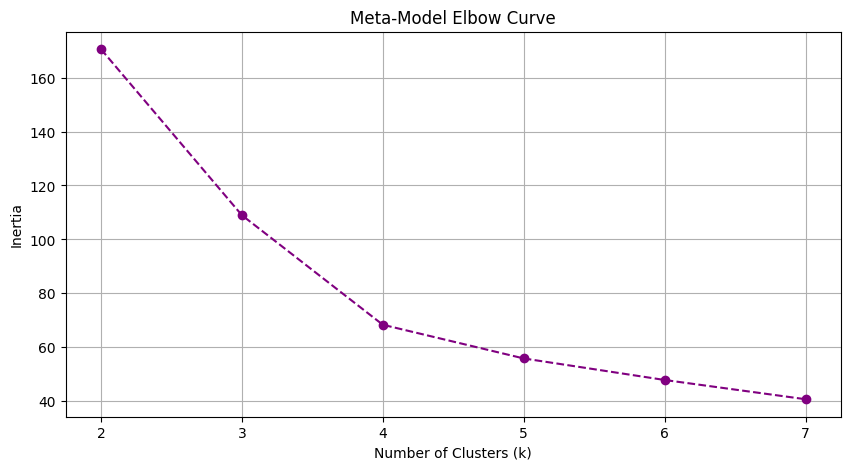

In [13]:
# Find optimal number of Meta-Clusters
inertia = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_meta_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', color='purple', linestyle='--')
plt.title('Meta-Model Elbow Curve')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [14]:
# Choose k based on the elbow (let's assume 4 for this archetype model)
best_k = 4 
meta_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_meta['Meta_Cluster'] = meta_km.fit_predict(X_meta_scaled)

In [15]:
df_meta.head()

,Career_Cluster,Performance_Cluster,Meta_Cluster
0,0,2.0,1
1,6,0.0,0
2,4,0.0,0
3,4,0.0,0
4,7,1.0,0


In [16]:
# Calculate Silhouette Score
score = silhouette_score(X_meta_scaled, df_meta['Meta_Cluster'])
print(f"Average Silhouette Score for Meta-Model: {score:.4f}")

Average Silhouette Score for Meta-Model: 0.4547


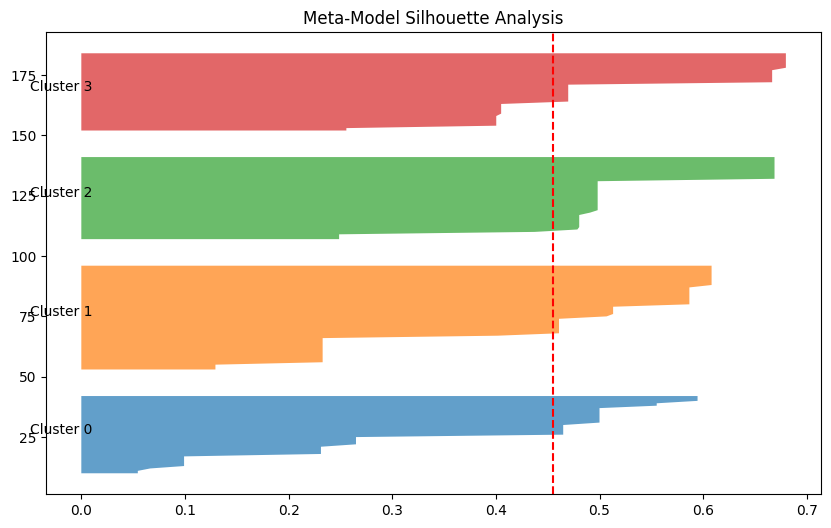

In [17]:
# Silhouette Plot Visualization
sample_values = silhouette_samples(X_meta_scaled, df_meta['Meta_Cluster'])
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(best_k):
    ith_cluster_v = sample_values[df_meta['Meta_Cluster'] == i]
    ith_cluster_v.sort()
    y_upper = y_lower + len(ith_cluster_v)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_v, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * len(ith_cluster_v), f'Cluster {i}')
    y_lower = y_upper + 10
plt.axvline(x=score, color='red', linestyle='--')
plt.title('Meta-Model Silhouette Analysis')
plt.show()

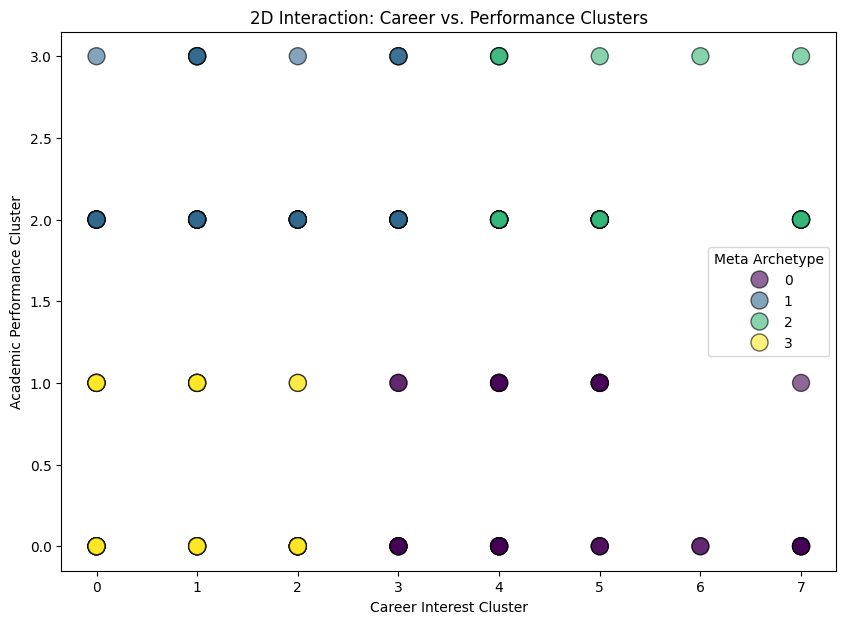

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_meta, 
    x='Career_Cluster', 
    y='Performance_Cluster', 
    hue='Meta_Cluster', 
    palette='viridis', 
    s=150, 
    alpha=0.6,
    edgecolor='black'
)
plt.title('2D Interaction: Career vs. Performance Clusters')
plt.xlabel('Career Interest Cluster')
plt.ylabel('Academic Performance Cluster')
plt.legend(title='Meta Archetype')
plt.show()

In [19]:
# Convert Cluster to String for distinct, high-contrast colors (fixes overlap)
df_meta['Archetype_Name'] = df_meta['Meta_Cluster'].astype(str)

fig = px.scatter_3d(
    df_meta,
    x='Career_Cluster',
    y='Performance_Cluster',
    z='Meta_Cluster',
    color='Archetype_Name',
    title="Interactive 3D Student Archetypes",
    labels={
        'Career_Cluster': 'Career Dimension', 
        'Performance_Cluster': 'Performance Dimension',
        'Meta_Cluster': 'Archetype Index'
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    template="plotly_dark"
)

# This will be interactive in your VS Code window (scroll to zoom, drag to move)
fig.show()

In [20]:
df_meta.head()

,Career_Cluster,Performance_Cluster,Meta_Cluster,Archetype_Name
0,0,2.0,1,1
1,6,0.0,0,0
2,4,0.0,0,0
3,4,0.0,0,0
4,7,1.0,0,0


In [21]:
import pickle
with open('higher.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

NameError: name 'kmeans' is not defined